In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

Path("outputs").mkdir(parents=True, exist_ok=True)

# Load country-level view
country_month = pd.read_csv("data/processed/country_month_view.csv", parse_dates=["period"])

def forecast_country(df, country_name, n_forecast=6):
    """Fit SARIMA to one country's 4-hour % and forecast n_forecast months ahead."""
    country_df = df[df["country"] == country_name].sort_values("period").set_index("period")
    series = country_df["pct_4hr_type1"]
    
    # Fit SARIMA — standard configuration for monthly data with 12-month seasonality
    # (1,1,1)(1,1,1,12) — one of the most common starting configurations
    model = SARIMAX(
        series,
        order=(1, 1, 1),                    # non-seasonal AR, integration, MA
        seasonal_order=(1, 1, 1, 12),       # seasonal AR, integration, MA, seasonality period=12 months
    )
    fitted = model.fit(disp=False)
    
    # Forecast n_forecast months ahead
    forecast = fitted.get_forecast(steps=n_forecast)
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int(alpha=0.05)  # 95% confidence interval
    
    # Build a clean output table
    result = pd.DataFrame({
        "country": country_name,
        "period": forecast_mean.index,
        "forecast_pct_4hr": forecast_mean.values.round(1),
        "lower_95": forecast_ci.iloc[:, 0].values.round(1),
        "upper_95": forecast_ci.iloc[:, 1].values.round(1),
    })
    return result, fitted, series

# Run for both countries
england_forecast, eng_model, eng_series = forecast_country(country_month, "England", n_forecast=8)
scotland_forecast, sco_model, sco_series = forecast_country(country_month, "Scotland", n_forecast=8)

# Print forecasts
print("ENGLAND — SARIMA forecast, 6 months forward")
print("=" * 60)
print(england_forecast.to_string(index=False))

print("\nSCOTLAND — SARIMA forecast, 6 months forward")
print("=" * 60)
print(scotland_forecast.to_string(index=False))

ENGLAND — SARIMA forecast, 6 months forward
country     period  forecast_pct_4hr  lower_95  upper_95
England 2026-05-01              64.4      59.8      69.1
England 2026-06-01              63.5      56.4      70.6
England 2026-07-01              63.2      54.5      71.8
England 2026-08-01              62.3      52.2      72.4
England 2026-09-01              60.7      49.4      72.0
England 2026-10-01              58.9      46.5      71.3
England 2026-11-01              58.3      44.9      71.7
England 2026-12-01              56.5      42.1      70.8

SCOTLAND — SARIMA forecast, 6 months forward
 country     period  forecast_pct_4hr  lower_95  upper_95
Scotland 2026-05-01              65.3      61.5      69.1
Scotland 2026-06-01              64.3      58.8      69.9
Scotland 2026-07-01              63.8      57.1      70.5
Scotland 2026-08-01              62.1      54.2      69.9
Scotland 2026-09-01              61.2      52.5      69.9
Scotland 2026-10-01              59.0      49.4  

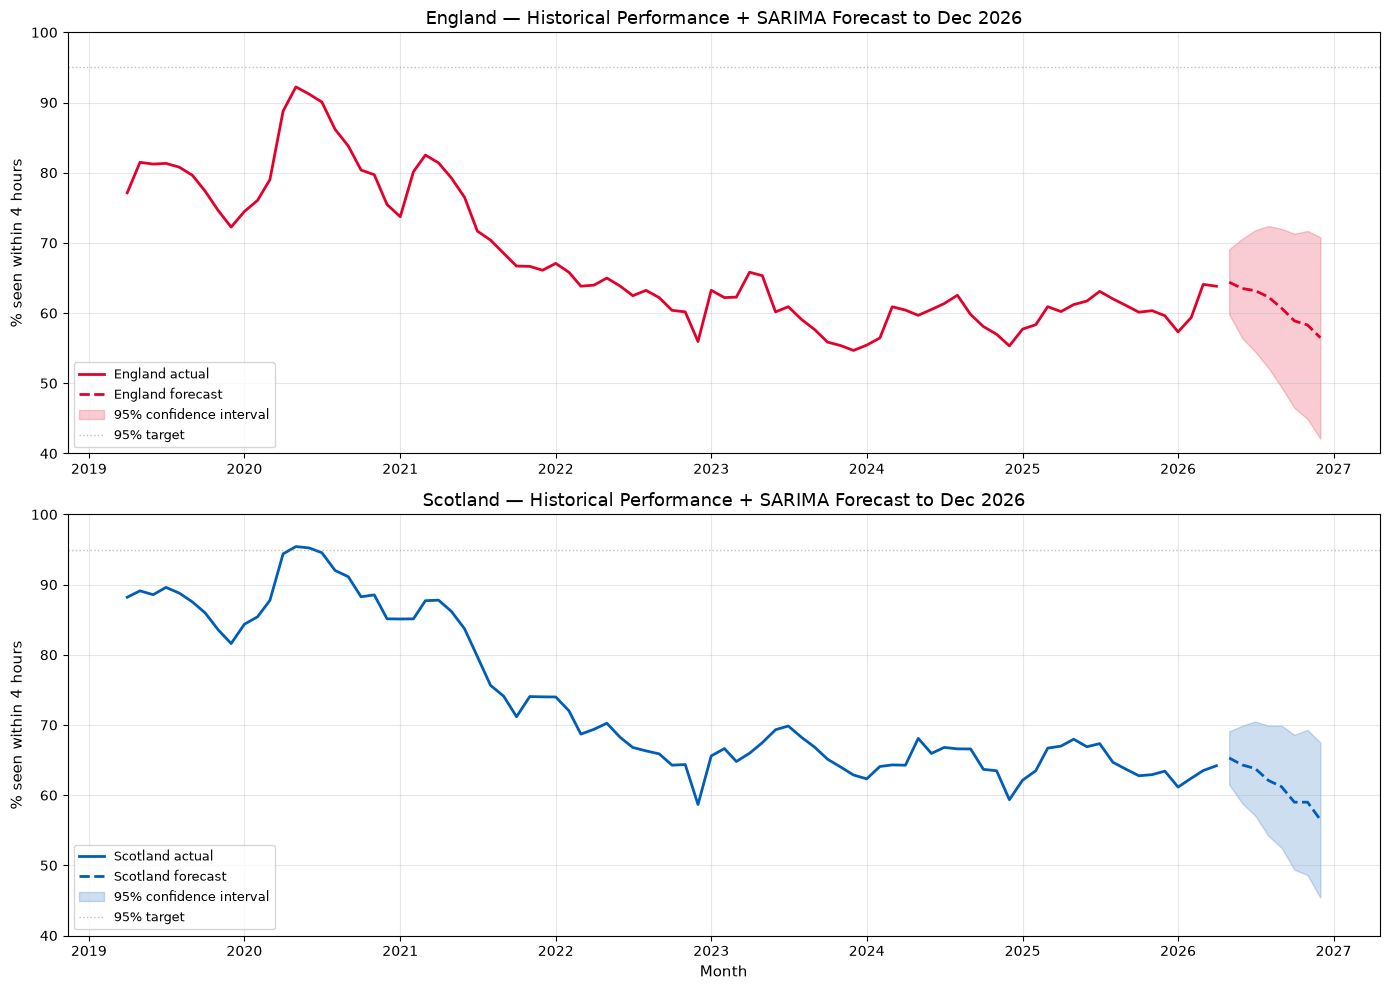

Saved forecast chart and tables to outputs/


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, country, colour, series, forecast in zip(
    axes, 
    ["England", "Scotland"], 
    ["#E4002B", "#005EB8"],
    [eng_series, sco_series],
    [england_forecast, scotland_forecast]
):
    # Plot historical actual
    ax.plot(series.index, series.values, color=colour, linewidth=2, label=f"{country} actual")
    
    # Plot forecast
    forecast_dates = pd.to_datetime(forecast["period"])
    ax.plot(forecast_dates, forecast["forecast_pct_4hr"], 
            color=colour, linewidth=2, linestyle="--", label=f"{country} forecast")
    
    # Plot confidence band
    ax.fill_between(forecast_dates, forecast["lower_95"], forecast["upper_95"],
                     color=colour, alpha=0.2, label="95% confidence interval")
    
    # Target line
    ax.axhline(y=95, color="grey", linestyle=":", linewidth=1, alpha=0.5, label="95% target")
    
    ax.set_title(f"{country} — Historical Performance + SARIMA Forecast to Dec 2026", fontsize=13)
    ax.set_ylabel("% seen within 4 hours", fontsize=11)
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(40, 100)

axes[1].set_xlabel("Month", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/q4_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

# Save forecast tables
england_forecast.to_csv("outputs/q4_england_forecast.csv", index=False)
scotland_forecast.to_csv("outputs/q4_scotland_forecast.csv", index=False)
print("Saved forecast chart and tables to outputs/")


# Q4: Eight-Month Performance Forecast (May → December 2026)

## The forecast
Using SARIMA a standard time-series model that combines trend, autoregressive patterns and 12-month seasonality. I forecast 4-hour performance for both countries through the rest of 2026.

**England forecast:** starting at 64.4% in May 2026, declining steadily to 56.5% by December an ~8 percentage-point drop across the winter.

**Scotland forecast:** starting at 65.3% in May, ending at 56.5% in December an ~9 point drop.

Both countries converge on the same point (56.5%) by December despite independently fitted models. That reinforces the Q1 finding that Scotland's historical lead has essentially disappeared — under similar recent trajectories and similar seasonal patterns, both countries end in the same place.

## What the model is capturing
SARIMA has seen six previous years of seasonal cycles: winter pressure hitting hardest in November-January, spring recovery, summer plateau, autumn decline. The forecast is essentially "if 2026 behaves like 2019-2025 did, this is what happens." It captures trend + seasonality, not shocks.

## Honesty about uncertainty
Confidence intervals widen substantially over the forecast horizon. By May 2026 the England interval is ~9 percentage points wide; by December it's nearly 30. That's not a failure it's the model being honest about how quickly forecast uncertainty compounds. Anyone quoting the point forecast (56.5%) for December without the range (42–71) would be overstating what the model actually knows.

## What SARIMA cannot see
The model cannot forecast structural change  a policy intervention, a new COVID wave, an NHS reform, a bad flu season, a workforce dispute. It answers "what happens if current conditions continue?", not "what will actually happen?". For operational planning through the winter, that's a useful baseline. For strategic planning past three months, it's a reference point, not a prediction.

## Comparison to my initial expectation
Before running the model I predicted the forecast would show steady improvement, based on 2026's spring numbers rising above 2025's. Once fitted, SARIMA disagreed showing seasonal decline into winter. On reflection, what I read as "trend rising" was in fact spring seasonal recovery. SARIMA decomposes those effects properly; eyeballing a chart doesn't.
